In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================

# Data Exploration - Dataset 2024-2025

# =====================================================================


This section presents an in-depth exploratory analysis of the 5G dataset for years 2024-2025.

## 1. Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

✅ Dataset loaded successfully!
📊 Dataset dimensions: 210,528 rows × 23 columns
📅 Period covered: 2024-01-01 00:00:23 to 2025-12-31 23:55:00


## 2. Data Overview

In [3]:
# Display first rows
print(" First rows of the dataset:")
df.head(10)

 First rows of the dataset:


,timestamp,cell_id,ue_id,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type,year
0,2024-01-01 00:00:23,gNB-016,UE-AEAA6E25,eMBB,33.986761,-7.481772,8.2701,6.4668,20.0553,93.2862,17.2102,99.7344,0.384824,0.441866,6.925900,16319.8043,2345.7645,21.7308,99.5330,28127277.0,0,normal,2024
1,2024-01-01 00:05:07,gNB-021,UE-B96827BA,eMBB,33.924364,-7.688178,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal,2024
2,2024-01-01 00:10:21,gNB-025,UE-46F73B92,URLLC,33.874334,-7.592654,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal,2024
3,2024-01-01 00:14:31,gNB-011,UE-2A8D8A30,URLLC,33.986101,-7.489073,2.4752,0.6764,6.9553,0.6122,6.0127,99.9996,0.000431,0.000301,0.739801,55.8908,77.0901,10.8790,99.6506,759434233.0,0,normal,2024
4,2024-01-01 00:20:09,gNB-018,UE-075062B9,eMBB,33.722701,-7.533619,14.6547,15.7102,25.0057,71.8194,37.8084,99.1931,9.553508,5.002759,25.316400,4345.8090,3253.1430,5.7971,99.7065,63280249.0,1,interference,2024
5,2024-01-01 00:24:30,gNB-016,UE-D8FC5BAB,eMBB,33.988866,-7.479194,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal,2024
6,2024-01-01 00:30:07,gNB-039,UE-7DA9C694,eMBB,34.049315,-7.565690,14.3204,5.2519,23.5177,81.4161,32.6378,99.6232,0.217553,0.408593,3.608500,9913.5433,7944.7610,17.0016,99.3360,48074717.0,0,normal,2024
7,2024-01-01 00:34:43,gNB-015,UE-564696C8,mMTC,34.007053,-7.512526,67.2288,12.9222,109.6372,64.7531,17.2101,98.9795,1.767200,4.256400,11.990800,0.5861,0.2500,2.2229,99.4930,334484.0,0,normal,2024
8,2024-01-01 00:39:56,gNB-046,UE-73CE466D,eMBB,33.566391,-7.509194,16.0262,7.1611,29.8086,65.8165,23.0514,99.8974,0.345124,0.887558,1.940300,2843.3512,7239.5397,16.9488,99.5523,67758338.0,0,normal,2024
9,2024-01-01 00:45:17,gNB-025,UE-35ADA062,URLLC,33.891234,-7.590374,1.7702,0.5240,5.3336,0.5560,5.6382,99.9997,0.000646,0.000591,0.604592,137.0821,74.2707,13.4732,99.6981,411244962.0,0,normal,2024


In [4]:
# General information about the dataset
print(" General information:")
print(df.info())

 General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210528 entries, 0 to 210527
Data columns (total 23 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   timestamp                         210528 non-null  datetime64[ns]
 1   cell_id                           210528 non-null  object        
 2   ue_id                             210528 non-null  object        
 3   slice_type                        210528 non-null  object        
 4   latitude                          210528 non-null  float64       
 5   longitude                         210528 non-null  float64       
 6   one_way_latency_ms                210528 non-null  float64       
 7   jitter_ms                         210528 non-null  float64       
 8   rtt_ms                            210528 non-null  float64       
 9   packet_delay_budget_ms            210528 non-null  float64       
 10  handover_i

## 3. Data Quality Check

In [5]:
# Check for missing values
print("🔍 Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values detected!")
else:
    print(missing[missing > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔍 Duplicates: {duplicates:,} rows")

# Basic statistics
print("\n📊 Basic statistics:")
print(f"   Total number of records: {len(df):,}")
print(f"   Number of cells (gNB): {df['cell_id'].nunique()}")
print(f"   Number of UEs: {df['ue_id'].nunique()}")
print(f"   Slice types: {df['slice_type'].unique()}")

🔍 Missing values:
✅ No missing values detected!

🔍 Duplicates: 0 rows

📊 Basic statistics:
   Total number of records: 210,528
   Number of cells (gNB): 50
   Number of UEs: 500
   Slice types: ['eMBB' 'URLLC' 'mMTC']


## 4. Anomaly Analysis

🚨 Anomaly distribution:
anomaly
0    200032
1     10496
Name: count, dtype: int64

   Normal: 200,032 (95.01%)
   Anomalies: 10,496 (4.99%)

🔴 Anomaly types:
anomaly_type
security_attack       1381
interference          1344
hardware_failure      1328
overload              1324
backhaul_issue        1301
network_congestion    1294
signal_degradation    1263
handover_failure      1261
Name: count, dtype: int64


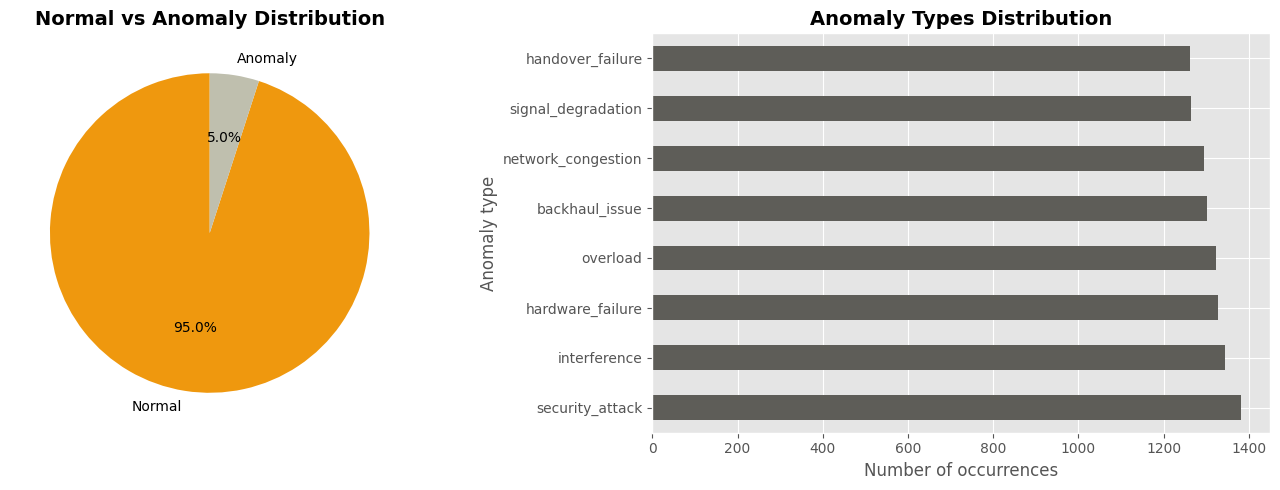

In [6]:
# Anomaly distribution
print("🚨 Anomaly distribution:")
anomaly_counts = df['anomaly'].value_counts()
print(anomaly_counts)
print(f"\n   Normal: {anomaly_counts[0]:,} ({anomaly_counts[0]/len(df)*100:.2f}%)")
print(f"   Anomalies: {anomaly_counts[1]:,} ({anomaly_counts[1]/len(df)*100:.2f}%)")

# Distribution of anomaly types
print("\n🔴 Anomaly types:")
anomaly_types = df[df['anomaly'] == 1]['anomaly_type'].value_counts()
print(anomaly_types)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Normal vs Anomaly
axes[0].pie(anomaly_counts, labels=['Normal', 'Anomaly'], autopct='%1.1f%%', 
            colors=["#ef980e", "#bfbfae"], startangle=90)
axes[0].set_title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')

# Chart 2: Anomaly types
anomaly_types.plot(kind='barh', ax=axes[1], color="#5e5d58")
axes[1].set_title('Anomaly Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of occurrences')
axes[1].set_ylabel('Anomaly type')

plt.tight_layout()
plt.show()

## 5. Slice Type Distribution

📡 Slice type distribution:
slice_type
eMBB     105214
URLLC     63196
mMTC      42118
Name: count, dtype: int64
   eMBB: 105,214 (50.0%)
   URLLC: 63,196 (30.0%)
   mMTC: 42,118 (20.0%)

🔴 Anomalies by slice type:
slice_type
URLLC    3101
eMBB     5255
mMTC     2140
dtype: int64


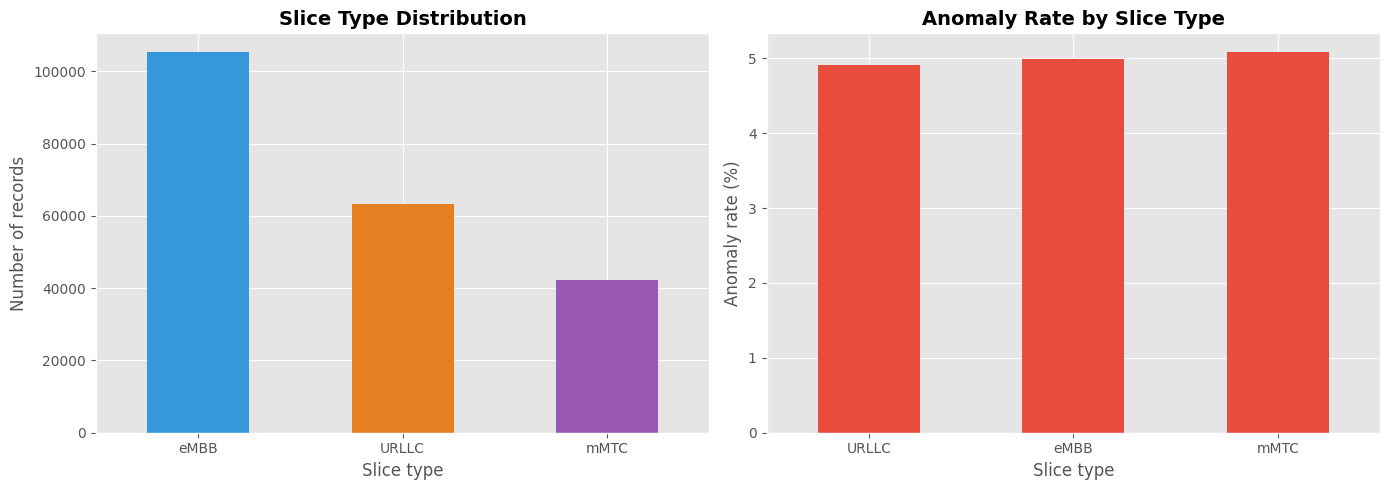

In [7]:
# Slice type distribution
print("📡 Slice type distribution:")
slice_counts = df['slice_type'].value_counts()
print(slice_counts)
for slice_type, count in slice_counts.items():
    print(f"   {slice_type}: {count:,} ({count/len(df)*100:.1f}%)")

# Anomalies by slice type
print("\n🔴 Anomalies by slice type:")
slice_anomalies = df[df['anomaly'] == 1].groupby('slice_type').size()
print(slice_anomalies)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Slice distribution
slice_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e67e22', '#9b59b6'])
axes[0].set_title('Slice Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Slice type')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Anomalies per slice
anomaly_rate_by_slice = df.groupby('slice_type')['anomaly'].mean() * 100
anomaly_rate_by_slice.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Anomaly Rate by Slice Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Slice type')
axes[1].set_ylabel('Anomaly rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. KPI Descriptive Statistics

In [8]:
# Select KPI columns (numeric)
kpi_columns = [col for col in df.columns if col not in 
               ['timestamp', 'cell_id', 'ue_id', 'slice_type', 'latitude', 
                'longitude', 'anomaly', 'anomaly_type']]

print(f"📊 Descriptive statistics for {len(kpi_columns)} KPIs:")
print(f"   KPIs: {', '.join(kpi_columns[:5])}... (+ {len(kpi_columns)-5} others)")

# Descriptive statistics
df[kpi_columns].describe()

📊 Descriptive statistics for 15 KPIs:
   KPIs: one_way_latency_ms, jitter_ms, rtt_ms, packet_delay_budget_ms, handover_interruption_time_ms... (+ 10 others)


,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year
count,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,210528.000000,2.105280e+05,210528.000000
mean,22.767039,6.132845,48.266612,53.947875,23.902414,99.004402,1.276615,1.277162,4.586971,4891.576979,2462.869502,13.490864,99.352843,1.758744e+08,2024.499316
std,81.083331,9.465414,159.917438,38.780783,29.859509,2.199454,3.788958,3.794859,5.031894,5702.360359,2838.525341,7.536970,2.024238,2.421146e+08,0.500001
min,0.120400,0.013100,0.546100,0.502200,0.555700,66.192300,0.000005,0.000003,0.001435,0.001200,0.002700,0.248700,59.378600,8.425000e+03,2024.000000
25%,3.525475,0.736675,7.542625,0.861700,7.281000,99.203000,0.000742,0.000743,0.720626,58.260500,58.394225,7.672000,99.343000,2.272843e+07,2024.000000
50%,9.707650,5.047700,23.684500,68.577950,23.394800,99.544800,0.458357,0.458202,4.110400,190.731500,186.902000,12.905650,99.498500,5.610600e+07,2024.000000
75%,16.617625,7.959625,34.640925,79.528250,33.780375,99.999300,0.816078,0.815131,6.640400,9794.954850,4887.701700,19.930400,99.653300,2.866249e+08,2025.000000
max,4211.906000,368.334300,8987.117500,468.237500,1030.412800,100.000000,53.413800,53.277200,80.000000,19965.238000,9943.524800,29.920600,99.996200,9.944150e+08,2025.000000


In [9]:
# KPI comparison: Normal vs Anomaly
#Les KPIs avec les plus grandes différences (%) sont les plus discriminants
print("📊 Average KPI comparison (Normal vs Anomaly):\n")

comparison = pd.DataFrame({
    'Normal (mean)': df[df['anomaly'] == 0][kpi_columns].mean(),
    'Anomaly (mean)': df[df['anomaly'] == 1][kpi_columns].mean(),
})
comparison['Difference (%)'] = ((comparison['Anomaly (mean)'] - comparison['Normal (mean)']) / 
                                 comparison['Normal (mean)'] * 100).round(2)

print(comparison)

# Interprétation automatique des résultats
print("\n" + "="*80)
print("🔍 INTERPRÉTATION DES RÉSULTATS")
print("="*80)

# Trier par valeur absolue de la différence
comparison_sorted = comparison.copy()
comparison_sorted['Abs_Diff'] = comparison_sorted['Difference (%)'].abs()
comparison_sorted = comparison_sorted.sort_values('Abs_Diff', ascending=False)

# Identifier les KPIs les plus discriminants
print("\n🎯 KPIs les plus discriminants (|Différence| > 50%) :")
highly_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] > 50]
if len(highly_discriminant) > 0:
    for kpi in highly_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        normal_val = comparison_sorted.loc[kpi, 'Normal (mean)']
        anomaly_val = comparison_sorted.loc[kpi, 'Anomaly (mean)']
        
        if diff > 0:
            trend = "↑ AUGMENTE"
            impact = "DÉGRADATION"
        else:
            trend = "↓ DIMINUE"
            impact = "DÉGRADATION" if "loss" in kpi.lower() or "error" in kpi.lower() else "AMÉLIORATION"
        
        print(f"   • {kpi}:")
        print(f"      Normal: {normal_val:.2f} → Anomaly: {anomaly_val:.2f} ({diff:+.1f}%)")
        print(f"      {trend} de {abs(diff):.1f}% → {impact}")
else:
    print("   Aucun KPI avec |Différence| > 50%")

print("\n🟡 KPIs modérément discriminants (20% < |Différence| < 50%) :")
moderately_discriminant = comparison_sorted[(comparison_sorted['Abs_Diff'] >= 20) & 
                                             (comparison_sorted['Abs_Diff'] <= 50)]
if len(moderately_discriminant) > 0:
    for kpi in moderately_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        print(f"   • {kpi}: {diff:+.1f}%")
else:
    print("   Aucun KPI dans cette catégorie")

print("\n🟢 KPIs peu discriminants (|Différence| < 20%) :")
low_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] < 20]
if len(low_discriminant) > 0:
    print(f"   • {len(low_discriminant)} KPI(s): {', '.join(low_discriminant.index[:5].tolist())}")
    if len(low_discriminant) > 5:
        print(f"     ... et {len(low_discriminant)-5} autres")
else:
    print("   Aucun KPI dans cette catégorie")

# Recommandations
print("\n💡 RECOMMANDATIONS :")
print(f"   ✓ Utiliser les {len(highly_discriminant)} KPIs fortement discriminants comme features principales")
print(f"   ✓ Définir des seuils d'alerte basés sur les valeurs moyennes observées")
print(f"   ✓ Les KPIs peu discriminants peuvent être exclus du modèle pour simplifier")
print(f"   ✓ Total de KPIs analysés: {len(comparison)} KPIs")

print("\n" + "="*80)

📊 Average KPI comparison (Normal vs Anomaly):

                                  Normal (mean)  Anomaly (mean)  \
one_way_latency_ms                 1.701398e+01    1.324084e+02   
jitter_ms                          5.398839e+00    2.012149e+01   
rtt_ms                             3.605797e+01    2.809380e+02   
packet_delay_budget_ms             5.269803e+01    7.776726e+01   
handover_interruption_time_ms      2.231732e+01    5.411100e+01   
reliability_percent                9.924972e+01    9.432914e+01   
packet_loss_percent                7.496344e-01    1.131977e+01   
packet_loss_rate_percent           7.490403e-01    1.134207e+01   
bler_percent                       4.147196e+00    1.296817e+01   
throughput_dl_mbps                 5.058553e+03    1.709355e+03   
throughput_ul_mbps                 2.544330e+03    9.103931e+02   
spectral_efficiency_bps_hz         1.359402e+01    1.152495e+01   
handover_success_rate_percent      9.950015e+01    9.654540e+01   
energy_efficien

## 7. Key KPI Visualization by Discrimination Level

🎯 9 KPIs très discriminants:


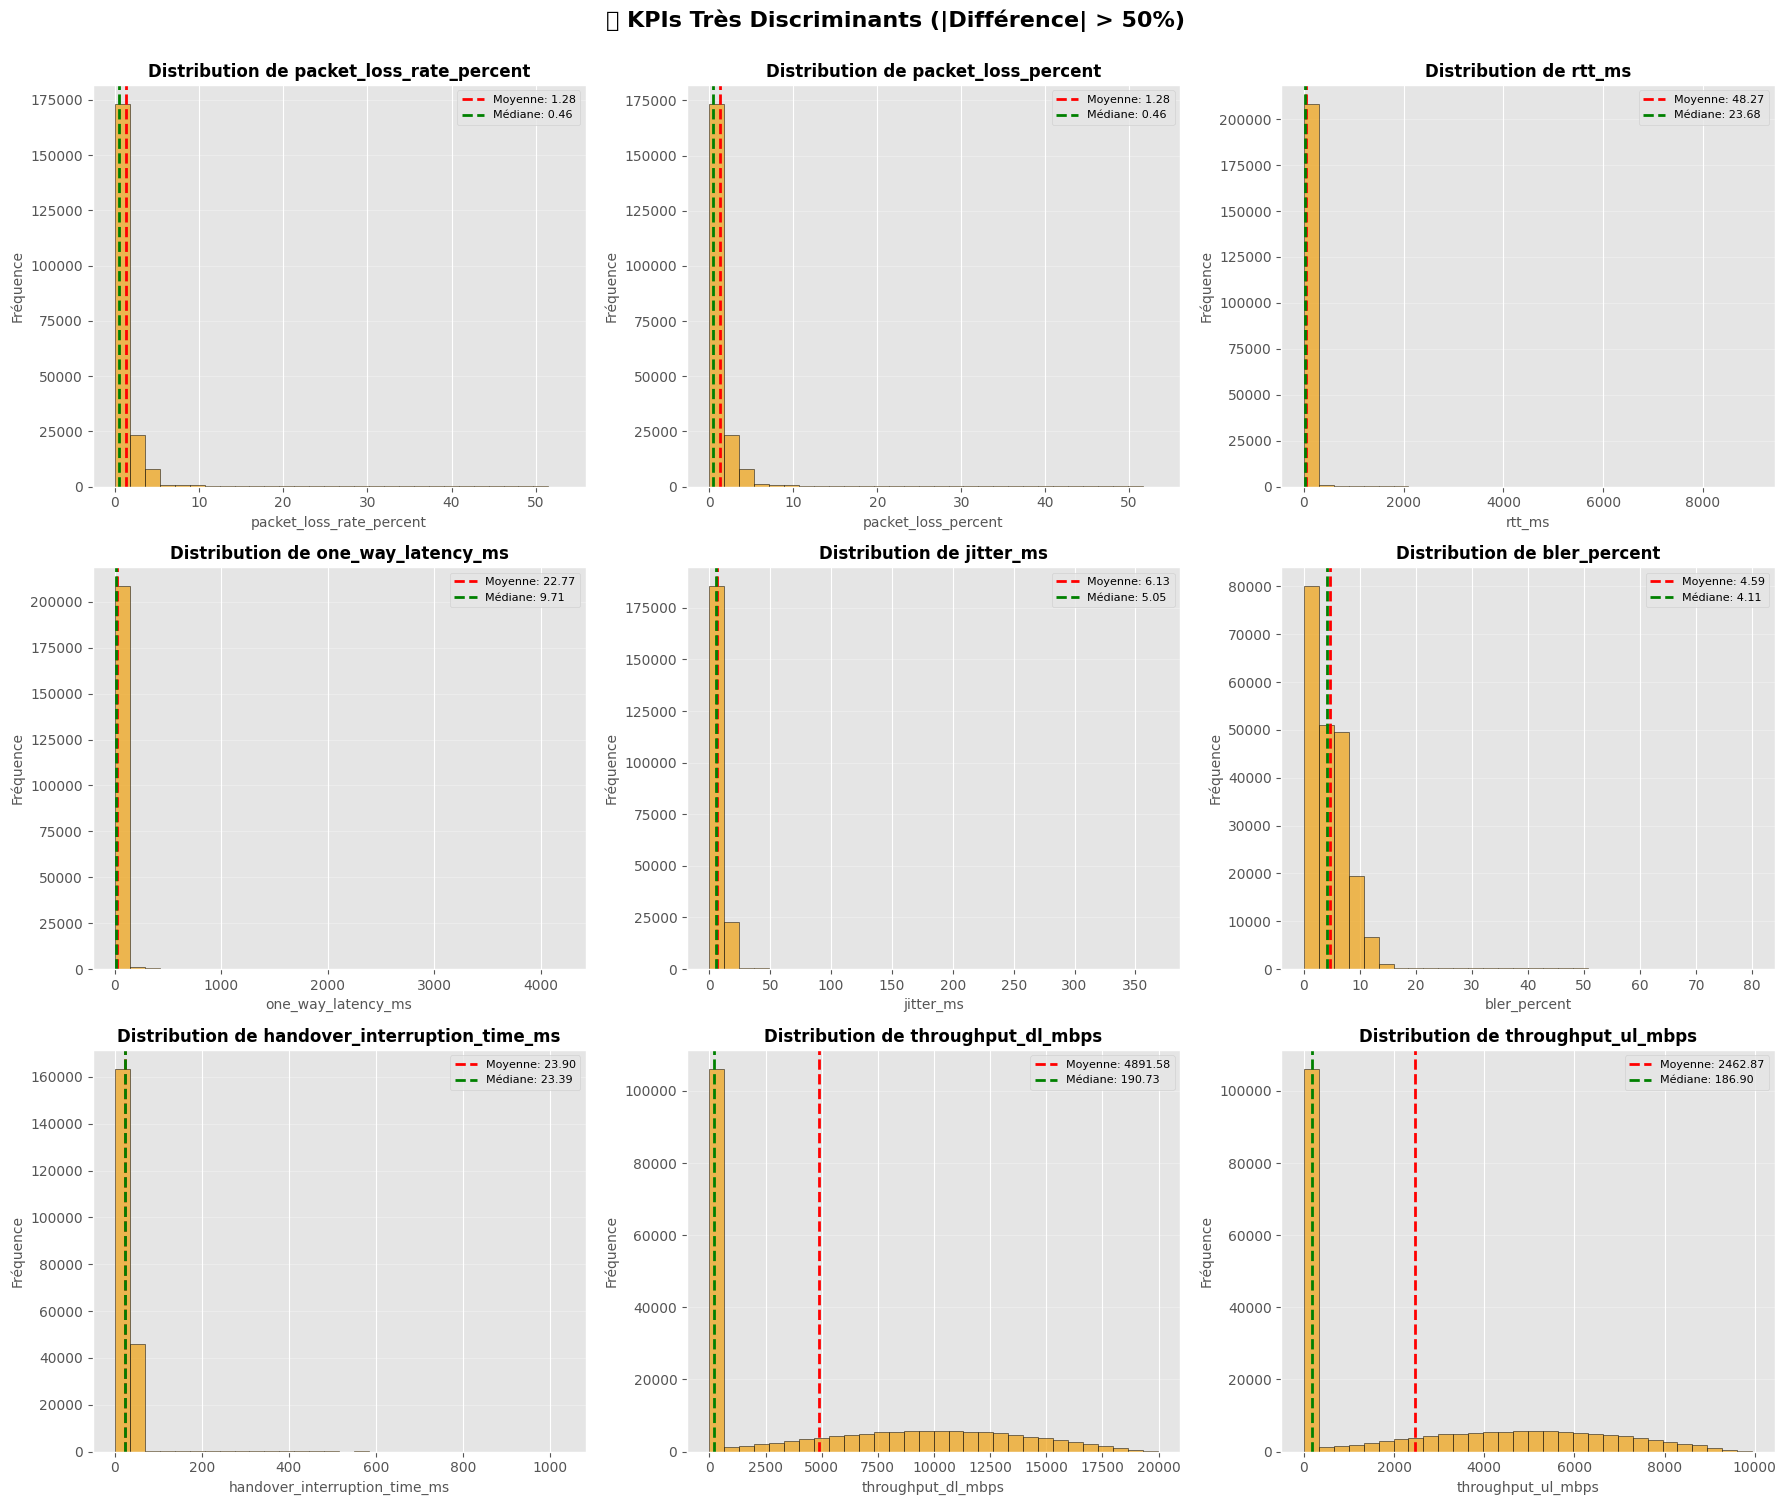


🟡 1 KPIs modérément discriminants:


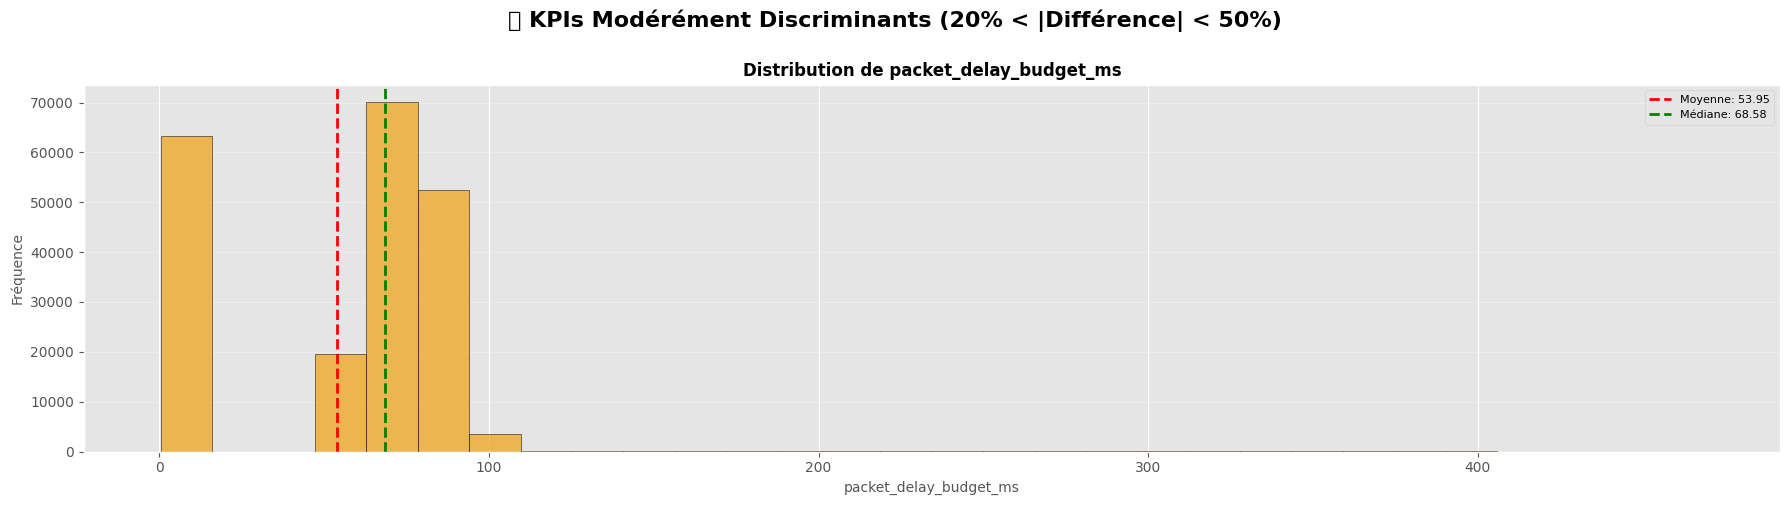


🟢 5 KPIs peu discriminants:


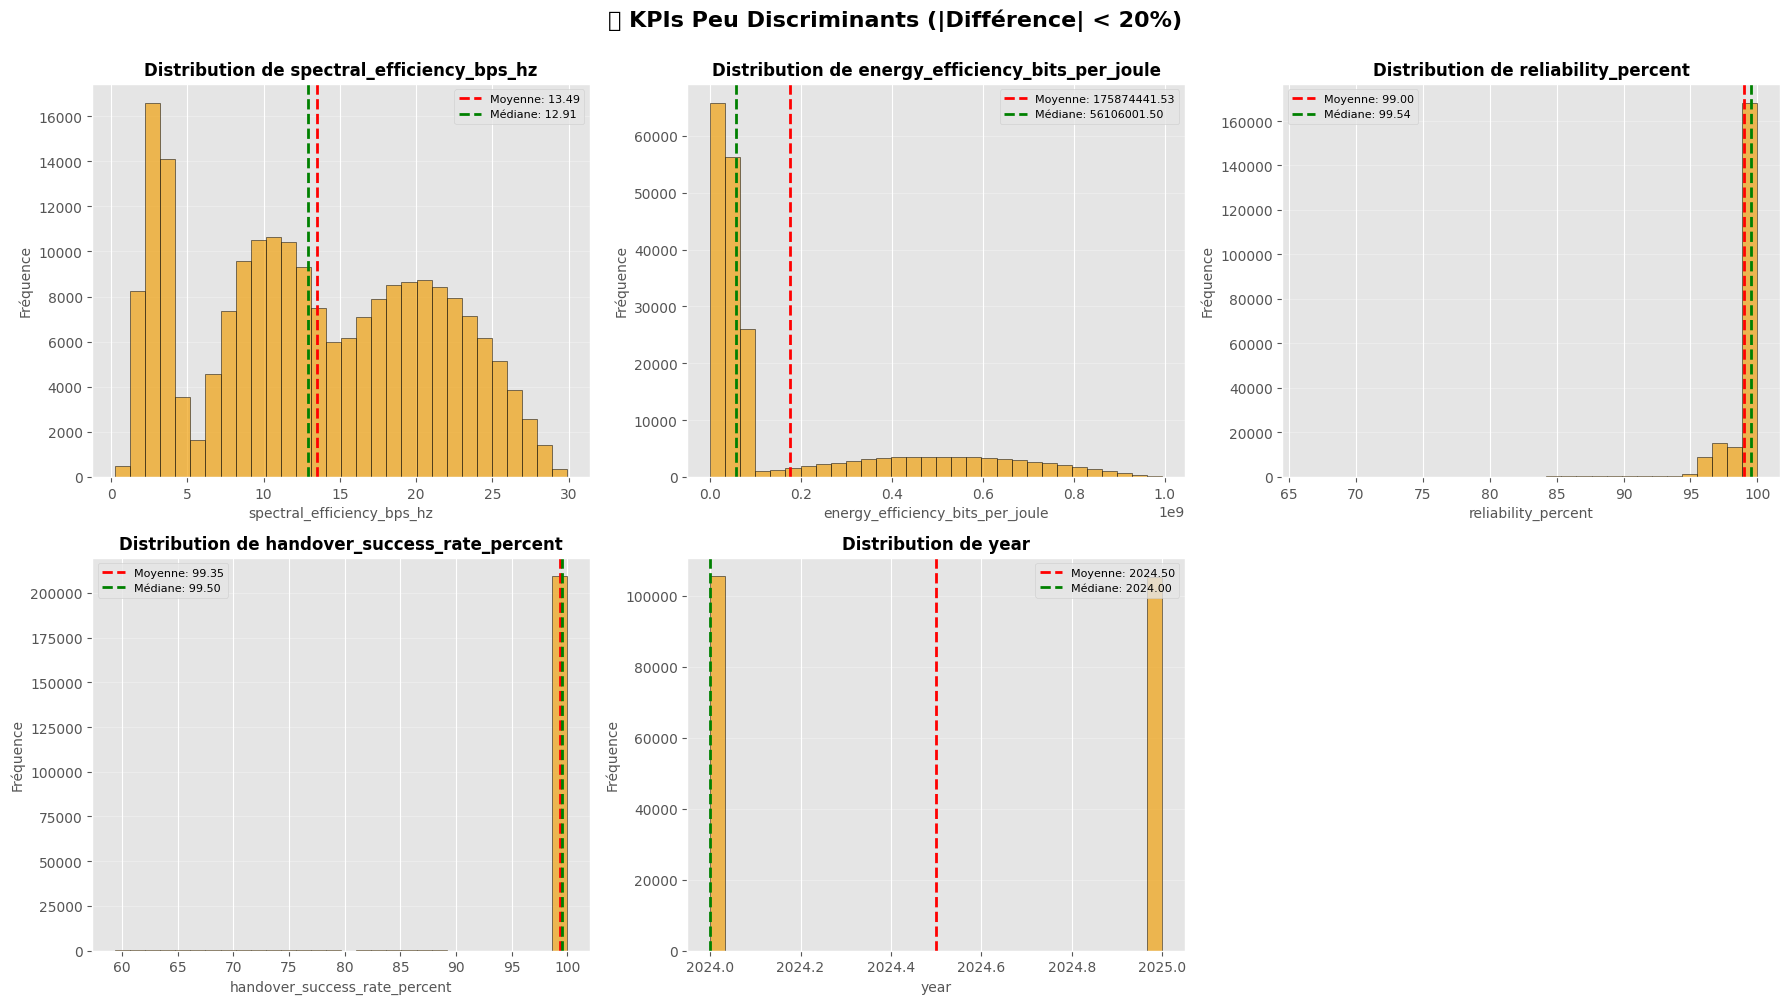

In [10]:
# =====================================================================
# Visualisation de TOUS les KPIs groupés par niveau de discrimination
# =====================================================================

# Calculer les groupes de KPIs
comparison_analysis = comparison.copy()
comparison_analysis['Abs_Diff'] = comparison_analysis['Difference (%)'].abs()

highly_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] > 50].sort_values('Abs_Diff', ascending=False).index.tolist()
moderately_discriminant_kpis = comparison_analysis[(comparison_analysis['Abs_Diff'] >= 20) & (comparison_analysis['Abs_Diff'] <= 50)].sort_values('Abs_Diff', ascending=False).index.tolist()
low_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] < 20].sort_values('Abs_Diff', ascending=False).index.tolist()

# Fonction pour créer les histogrammes d'un groupe
def plot_kpi_group(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ Aucun KPI dans le groupe: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    for idx, kpi in enumerate(kpis):
        axes[idx].hist(df[kpi], bins=30, color="#f0a10f",
                       alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution de {kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(kpi, fontsize=10)
        axes[idx].set_ylabel('Fréquence', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

        # Statistiques: moyenne et médiane
        mean_val = df[kpi].mean()
        median_val = df[kpi].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--',
                          linewidth=2, label=f'Moyenne: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--',
                          linewidth=2, label=f'Médiane: {median_val:.2f}')
        axes[idx].legend(fontsize=8)
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- BLOC 1: KPIs très discriminants (|Diff| > 50%) ---
print(f"🎯 {len(highly_discriminant_kpis)} KPIs très discriminants:")
plot_kpi_group(highly_discriminant_kpis, 
               '🎯 KPIs Très Discriminants (|Différence| > 50%)')

# --- BLOC 2: KPIs modérément discriminants (20-50%) ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} KPIs modérément discriminants:")
plot_kpi_group(moderately_discriminant_kpis, 
               '🟡 KPIs Modérément Discriminants (20% < |Différence| < 50%)')

# --- BLOC 3: KPIs peu discriminants (<20%) ---
print(f"\n🟢 {len(low_discriminant_kpis)} KPIs peu discriminants:")
plot_kpi_group(low_discriminant_kpis, 
               '🟢 KPIs Peu Discriminants (|Différence| < 20%)')



🎯 9 KPIs très discriminants (Box Plots):


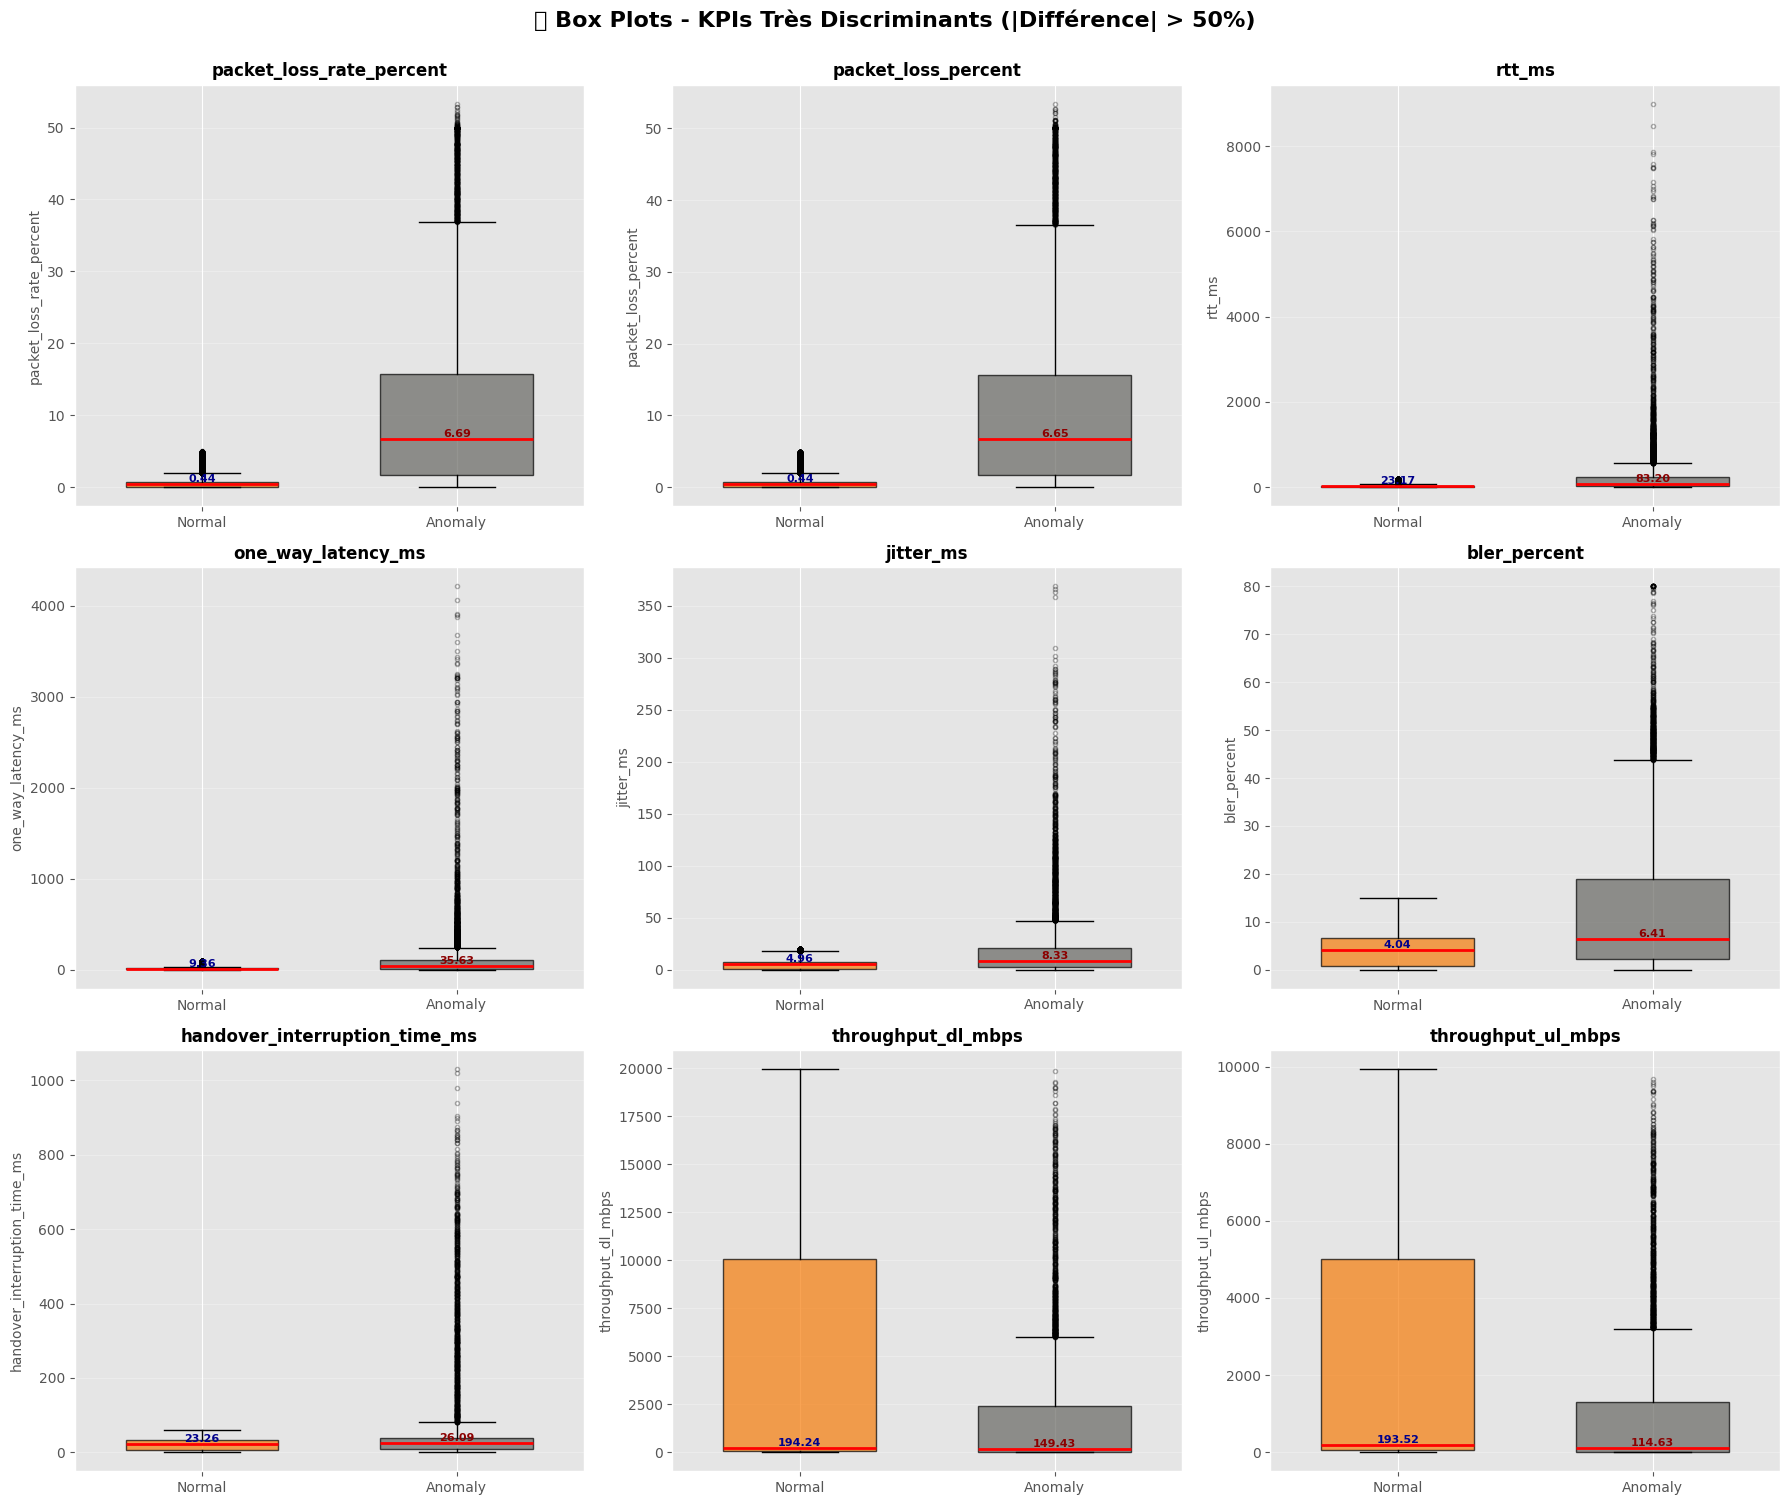


🟡 1 KPIs modérément discriminants (Box Plots):


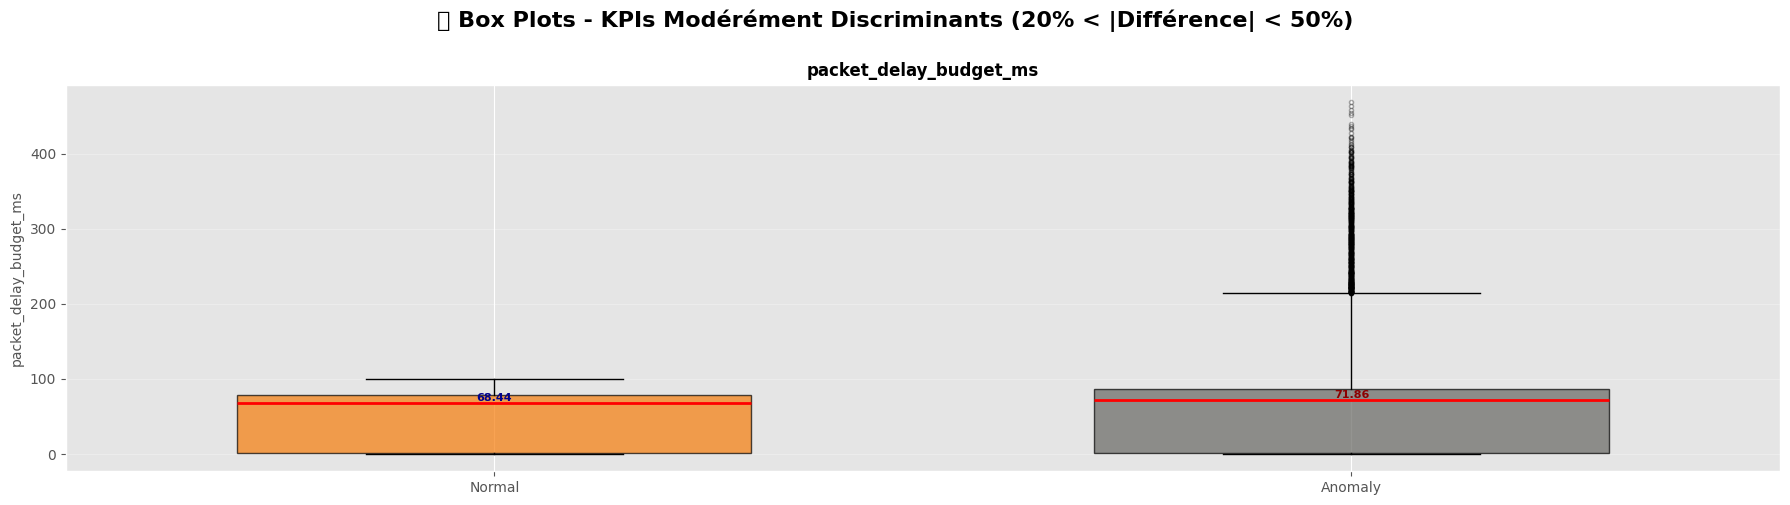


🟢 5 KPIs peu discriminants (Box Plots):


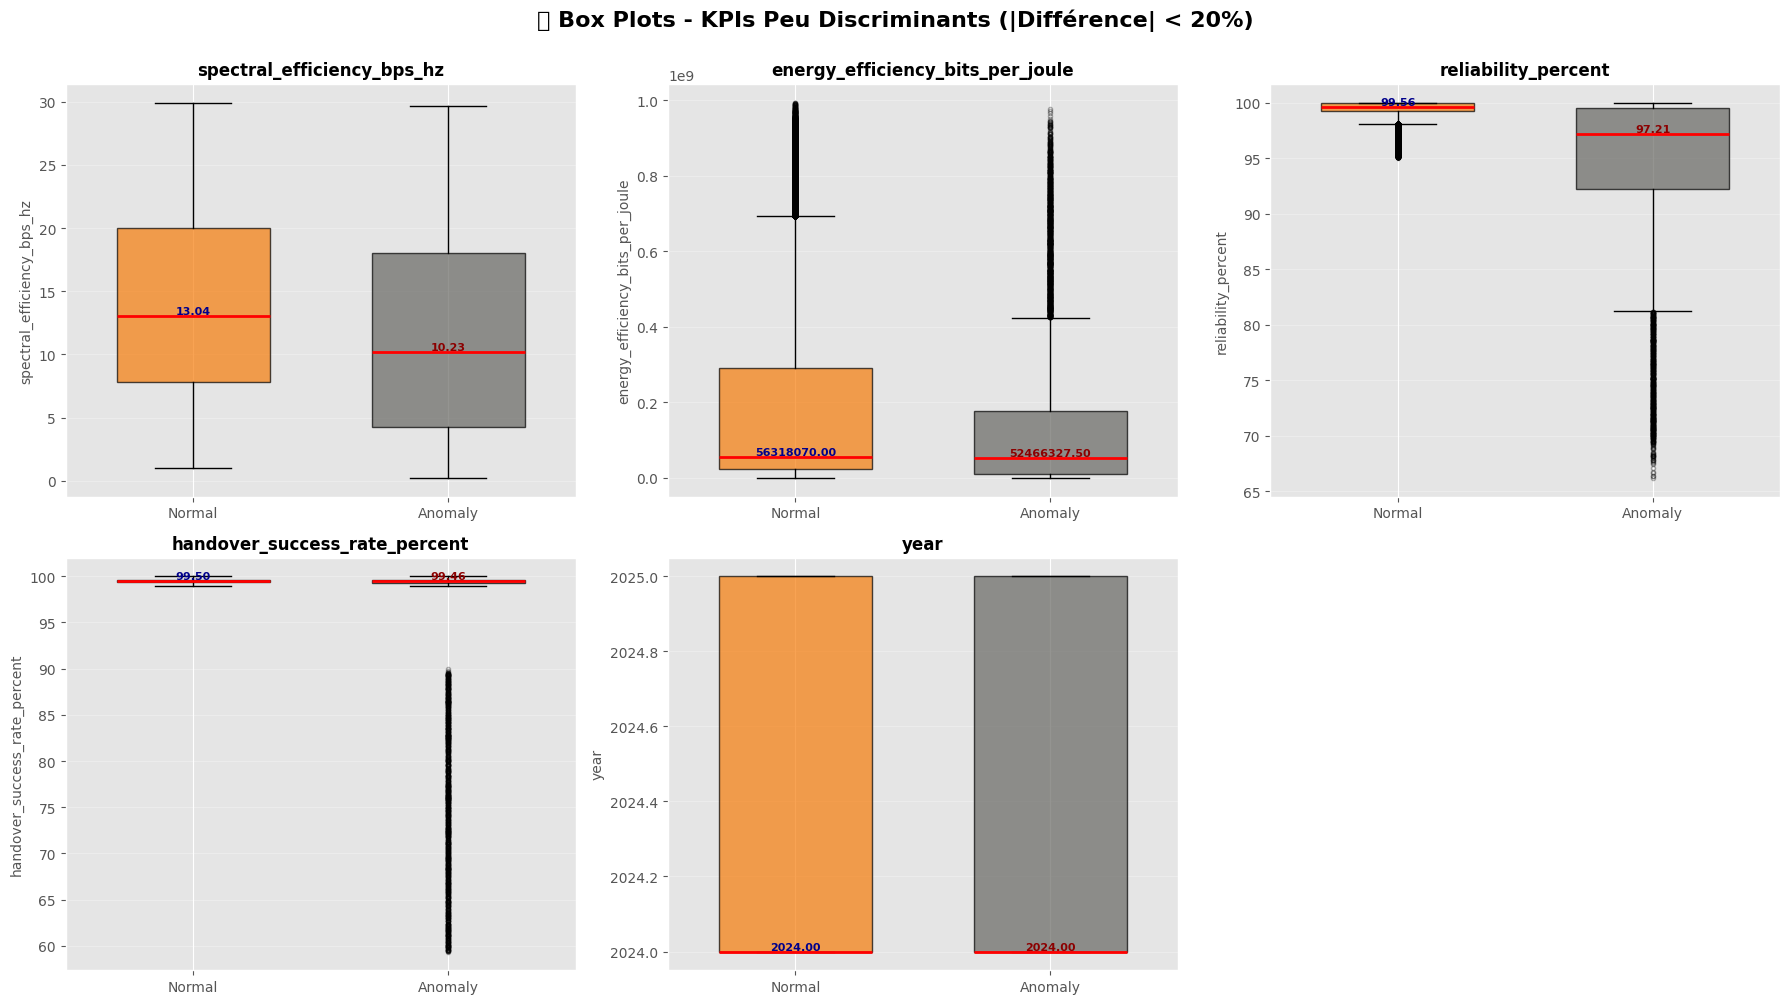

In [11]:
# =====================================================================
# Box Plots de TOUS les KPIs groupés par niveau de discrimination
# Normal vs Anomaly
# =====================================================================

def plot_kpi_boxplots(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ Aucun KPI dans le groupe: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    
    for idx, kpi in enumerate(kpis):
        data_normal = df[df['anomaly'] == 0][kpi]
        data_anomaly = df[df['anomaly'] == 1][kpi]
        
        bp = axes[idx].boxplot([data_normal, data_anomaly],
                               labels=['Normal', 'Anomaly'],
                               patch_artist=True,
                               widths=0.6,
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='o', markersize=3, alpha=0.3))
        
        # Couleurs des boîtes
        bp['boxes'][0].set_facecolor("#f67c0a")
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor("#676762")
        bp['boxes'][1].set_alpha(0.7)
        
        axes[idx].set_title(f'{kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(kpi, fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Annoter les médianes
        med_n = data_normal.median()
        med_a = data_anomaly.median()
        axes[idx].annotate(f'{med_n:.2f}', xy=(1, med_n), fontsize=8, 
                          color='darkblue', fontweight='bold', ha='center', va='bottom')
        axes[idx].annotate(f'{med_a:.2f}', xy=(2, med_a), fontsize=8, 
                          color='darkred', fontweight='bold', ha='center', va='bottom')
    
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- BLOC 1: KPIs très discriminants ---
print(f"🎯 {len(highly_discriminant_kpis)} KPIs très discriminants (Box Plots):")
plot_kpi_boxplots(highly_discriminant_kpis, 
                  '🎯 Box Plots - KPIs Très Discriminants (|Différence| > 50%)')

# --- BLOC 2: KPIs modérément discriminants ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} KPIs modérément discriminants (Box Plots):")
plot_kpi_boxplots(moderately_discriminant_kpis, 
                  '🟡 Box Plots - KPIs Modérément Discriminants (20% < |Différence| < 50%)')

# --- BLOC 3: KPIs peu discriminants ---
print(f"\n🟢 {len(low_discriminant_kpis)} KPIs peu discriminants (Box Plots):")
plot_kpi_boxplots(low_discriminant_kpis, 
                  '🟢 Box Plots - KPIs Peu Discriminants (|Différence| < 20%)')

## 7.bis Tests Statistiques 

Tests statistiques pour répondre aux questions métier clés du réseau 5G.

In [12]:
from scipy import stats

print("="*90)
print("📊 TESTS STATISTIQUES - BUSINESS UNDERSTANDING")
print("="*90)

# =====================================================================
# Q1: Les anomalies dégradent-elles SIGNIFICATIVEMENT les KPIs réseau ?
# Test de Mann-Whitney U (non paramétrique) pour chaque KPI
# =====================================================================
print("\n" + "─"*90)
print("❓ Q1: Les anomalies dégradent-elles significativement les KPIs réseau ?")
print("   Test: Mann-Whitney U (comparaison Normal vs Anomaly pour chaque KPI)")
print("─"*90)

mann_whitney_results = []
for kpi in kpi_columns:
    normal_vals = df[df['anomaly'] == 0][kpi].dropna()
    anomaly_vals = df[df['anomaly'] == 1][kpi].dropna()
    stat, p_value = stats.mannwhitneyu(normal_vals, anomaly_vals, alternative='two-sided')
    mann_whitney_results.append({
        'KPI': kpi,
        'U-Statistic': round(stat, 2),
        'P-Value': p_value,
        'Significatif (p<0.05)': '✅ OUI' if p_value < 0.05 else '❌ NON',
        'Interprétation': 'Différence significative' if p_value < 0.05 else 'Pas de différence'
    })

mw_df = pd.DataFrame(mann_whitney_results)
print(mw_df.to_string(index=False))

sig_count = sum(1 for r in mann_whitney_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_count}/{len(kpi_columns)} KPIs sont significativement différents entre Normal et Anomaly")
print(f"   → Les anomalies ont un impact statistiquement prouvé sur {sig_count} indicateurs réseau")

# =====================================================================
# Q2: Certains types de slice sont-ils plus vulnérables aux anomalies ?
# Test du Chi-deux d'indépendance (slice_type vs anomaly)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q2: Certains types de slice sont-ils plus vulnérables aux anomalies ?")
print("   Test: Chi-deux d'indépendance (slice_type × anomaly)")
print("─"*90)

contingency_table = pd.crosstab(df['slice_type'], df['anomaly'], margins=True)
print("\nTableau de contingence:")
print(contingency_table)

chi2, p_chi2, dof, expected = stats.chi2_contingency(
    pd.crosstab(df['slice_type'], df['anomaly'])
)
print(f"\n   Chi² = {chi2:.4f}")
print(f"   Degrés de liberté = {dof}")
print(f"   P-value = {p_chi2:.6f}")
print(f"   Résultat: {'✅ Dépendance significative' if p_chi2 < 0.05 else '❌ Indépendance'}")

if p_chi2 < 0.05:
    print(f"\n💡 Conclusion: Le type de slice influence SIGNIFICATIVEMENT le taux d'anomalies")
    anomaly_rates = df.groupby('slice_type')['anomaly'].mean() * 100
    most_vulnerable = anomaly_rates.idxmax()
    print(f"   → Slice la plus vulnérable: {most_vulnerable} ({anomaly_rates[most_vulnerable]:.2f}%)")
    least_vulnerable = anomaly_rates.idxmin()
    print(f"   → Slice la moins vulnérable: {least_vulnerable} ({anomaly_rates[least_vulnerable]:.2f}%)")
else:
    print(f"\n💡 Conclusion: Pas de lien significatif entre le type de slice et les anomalies")

# =====================================================================
# Q3: Y a-t-il une relation entre le type d'anomalie et le type de slice ?
# Test du Chi-deux (anomaly_type vs slice_type)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q3: Certains types d'anomalies sont-ils spécifiques à certains slices ?")
print("   Test: Chi-deux d'indépendance (anomaly_type × slice_type)")
print("─"*90)

df_anomalies = df[df['anomaly'] == 1]
contingency_anomaly_slice = pd.crosstab(df_anomalies['anomaly_type'], df_anomalies['slice_type'])
print("\nTableau de contingence (anomaly_type × slice_type):")
print(contingency_anomaly_slice)

chi2_as, p_as, dof_as, expected_as = stats.chi2_contingency(contingency_anomaly_slice)
print(f"\n   Chi² = {chi2_as:.4f}")
print(f"   P-value = {p_as:.6f}")
print(f"   Résultat: {'✅ Dépendance significative' if p_as < 0.05 else '❌ Indépendance'}")

if p_as < 0.05:
    print(f"\n💡 Conclusion: Certains types d'anomalies sont plus fréquents dans certains slices")
else:
    print(f"\n💡 Conclusion: Les anomalies se répartissent uniformément entre les slices")

# =====================================================================
# Q4: Les KPIs réseau suivent-ils une distribution normale ?
# Test de Shapiro-Wilk (sur un échantillon)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q4: Les KPIs suivent-ils une distribution normale ?")
print("   Test: Shapiro-Wilk (échantillon de 5000 observations)")
print("   → Important pour choisir les bons modèles ML")
print("─"*90)

shapiro_results = []
sample_size = min(5000, len(df))
for kpi in kpi_columns:
    sample = df[kpi].dropna().sample(n=sample_size, random_state=42)
    stat_sw, p_sw = stats.shapiro(sample)
    shapiro_results.append({
        'KPI': kpi,
        'Statistique W': round(stat_sw, 4),
        'P-Value': p_sw,
        'Distribution normale': '✅ OUI' if p_sw > 0.05 else '❌ NON'
    })

sw_df = pd.DataFrame(shapiro_results)
print(sw_df.to_string(index=False))

normal_count = sum(1 for r in shapiro_results if r['P-Value'] > 0.05)
print(f"\n💡 Conclusion: {normal_count}/{len(kpi_columns)} KPIs suivent une distribution normale")
if normal_count < len(kpi_columns) // 2:
    print(f"   → Privilégier des modèles non-paramétriques (Random Forest, KNN, etc.)")
else:
    print(f"   → Les modèles paramétriques (Régression Logistique, etc.) sont adaptés")

# =====================================================================
# Q5: Les KPIs varient-ils significativement selon le type d'anomalie ?
# Test de Kruskal-Wallis (comparaison entre tous les types d'anomalies)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q5: Les différents types d'anomalies ont-ils des signatures KPI distinctes ?")
print("   Test: Kruskal-Wallis (comparaison des KPIs entre types d'anomalies)")
print("─"*90)

kruskal_results = []
anomaly_types_list = df_anomalies['anomaly_type'].unique()

for kpi in kpi_columns:
    groups = [df_anomalies[df_anomalies['anomaly_type'] == at][kpi].dropna() 
              for at in anomaly_types_list]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat_kw, p_kw = stats.kruskal(*groups)
        kruskal_results.append({
            'KPI': kpi,
            'H-Statistic': round(stat_kw, 2),
            'P-Value': p_kw,
            'Significatif': '✅ OUI' if p_kw < 0.05 else '❌ NON'
        })

kw_df = pd.DataFrame(kruskal_results)
print(kw_df.to_string(index=False))

sig_kw = sum(1 for r in kruskal_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_kw}/{len(kruskal_results)} KPIs varient significativement selon le type d'anomalie")
if sig_kw > len(kruskal_results) // 2:
    print(f"   → Les types d'anomalies ont des signatures réseau DISTINCTES")
    print(f"   → Un modèle multi-classes peut identifier le TYPE d'anomalie (pas seulement sa présence)")
else:
    print(f"   → Les types d'anomalies sont difficiles à distinguer par les KPIs")


# =====================================================================
# RÉSUMÉ GLOBAL
# =====================================================================
print("\n" + "="*90)
print("📋 RÉSUMÉ GLOBAL DES TESTS STATISTIQUES")
print("="*90)
print(f"\n   Q1 - Impact des anomalies sur les KPIs:     {sig_count}/{len(kpi_columns)} KPIs impactés significativement")
print(f"   Q2 - Vulnérabilité par slice:                {'OUI - différences significatives' if p_chi2 < 0.05 else 'NON - pas de différence'}")
print(f"   Q3 - Anomalies spécifiques par slice:        {'OUI - dépendance significative' if p_as < 0.05 else 'NON - répartition uniforme'}")
print(f"   Q4 - Normalité des KPIs:                     {normal_count}/{len(kpi_columns)} KPIs normaux")
print(f"   Q5 - Signatures distinctes par type anomalie: {sig_kw}/{len(kruskal_results)} KPIs discriminants")



📊 TESTS STATISTIQUES - BUSINESS UNDERSTANDING

──────────────────────────────────────────────────────────────────────────────────────────
❓ Q1: Les anomalies dégradent-elles significativement les KPIs réseau ?
   Test: Mann-Whitney U (comparaison Normal vs Anomaly pour chaque KPI)
──────────────────────────────────────────────────────────────────────────────────────────
                             KPI  U-Statistic       P-Value Significatif (p<0.05)           Interprétation
              one_way_latency_ms  514455454.0  0.000000e+00                 ✅ OUI Différence significative
                       jitter_ms  689694329.5  0.000000e+00                 ✅ OUI Différence significative
                          rtt_ms  515749542.0  0.000000e+00                 ✅ OUI Différence significative
          packet_delay_budget_ms  890022572.5 1.104726e-152                 ✅ OUI Différence significative
   handover_interruption_time_ms  926794306.5  2.777120e-91                 ✅ OUI Différence

## 8. Correlation Matrix

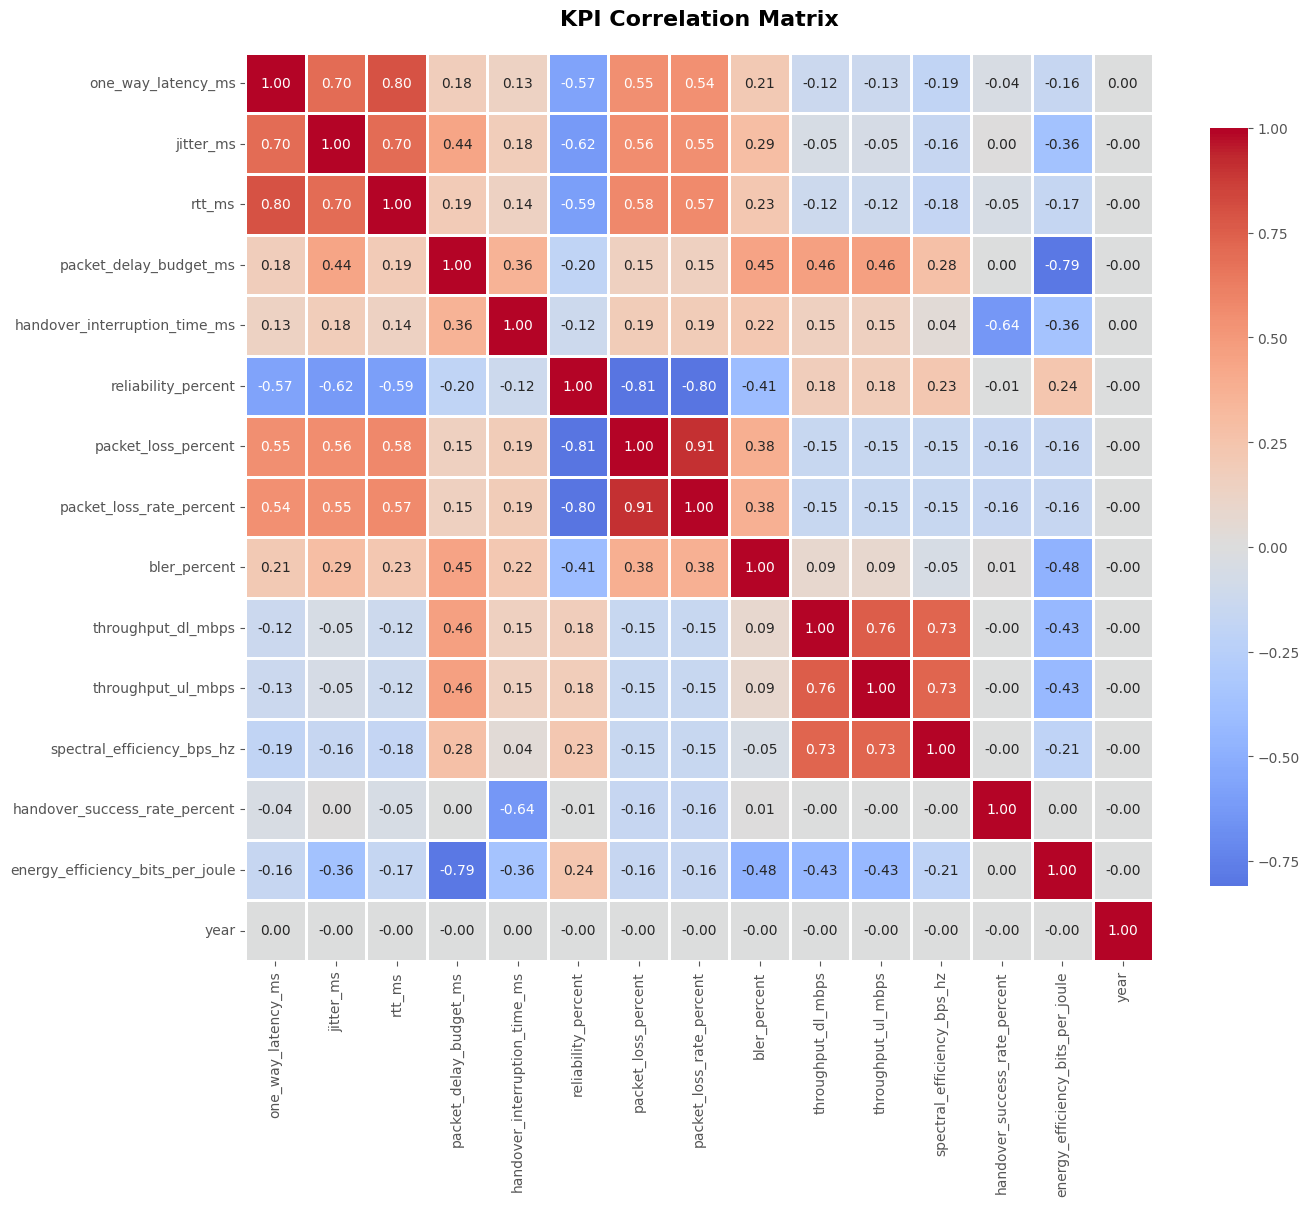


🔗 Strong correlations (|r| > 0.7):
                 KPI 1                            KPI 2  Correlation
    one_way_latency_ms                           rtt_ms        0.799
packet_delay_budget_ms energy_efficiency_bits_per_joule       -0.792
   reliability_percent              packet_loss_percent       -0.809
   reliability_percent         packet_loss_rate_percent       -0.804
   packet_loss_percent         packet_loss_rate_percent        0.905
    throughput_dl_mbps               throughput_ul_mbps        0.755
    throughput_dl_mbps       spectral_efficiency_bps_hz        0.726
    throughput_ul_mbps       spectral_efficiency_bps_hz        0.726


In [13]:
# KPI correlation matrix
correlation_matrix = df[kpi_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('KPI Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify strongest correlations (>0.7 or <-0.7)
print("\n🔗 Strong correlations (|r| > 0.7):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'KPI 1': correlation_matrix.columns[i],
                'KPI 2': correlation_matrix.columns[j],
                'Correlation': round(correlation_matrix.iloc[i, j], 3)
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlation detected.")

## 9. Temporal Analysis

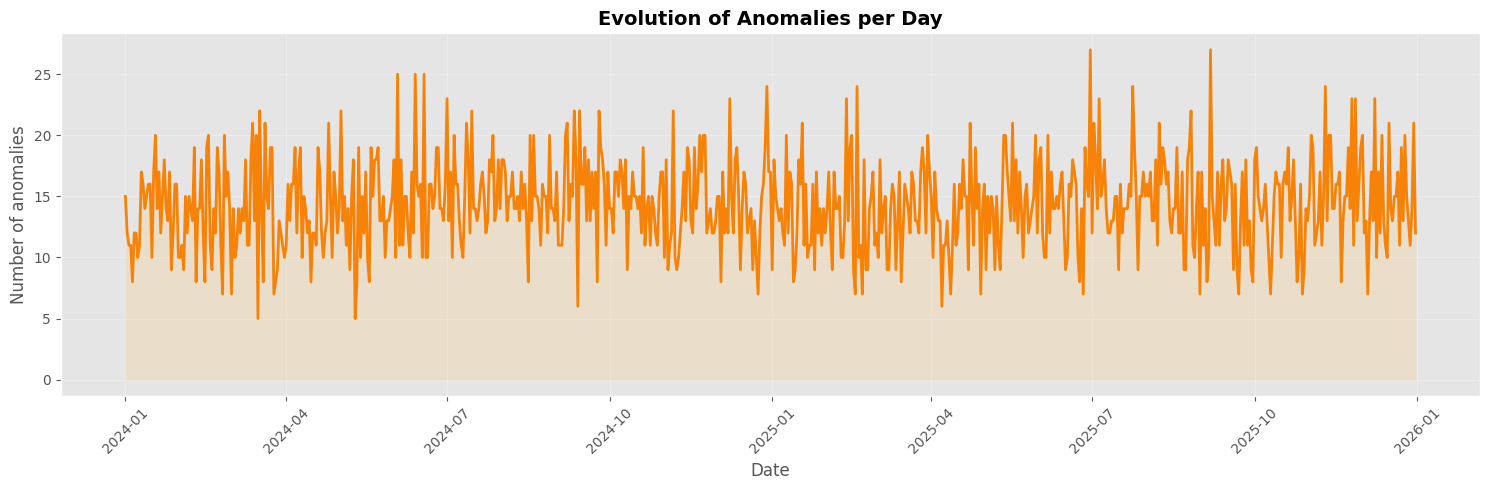

📅 Temporal statistics:
   Period covered: 2024-01-01 to 2025-12-31
   Number of days: 731
   Average anomaly rate per day: 4.99%


In [14]:
# Temporal evolution of anomalies
df['date'] = df['timestamp'].dt.date

# Anomalies per day
daily_anomalies = df.groupby('date')['anomaly'].agg(['sum', 'count'])
daily_anomalies['rate'] = (daily_anomalies['sum'] / daily_anomalies['count'] * 100)

# Visualization
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily_anomalies.index, daily_anomalies['sum'], color="#f68308", linewidth=2)
ax.fill_between(daily_anomalies.index, daily_anomalies['sum'], alpha=0.3, color="#F6CF8F")
ax.set_title('Evolution of Anomalies per Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of anomalies')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📅 Temporal statistics:")
print(f"   Period covered: {df['date'].min()} to {df['date'].max()}")
print(f"   Number of days: {df['date'].nunique()}")
print(f"   Average anomaly rate per day: {daily_anomalies['rate'].mean():.2f}%")